# 5. Diversity analysis


In this notebook we walk through the full diversity analysis workflow for our dataset. We start by exploring sequencing depth using alpha rarefaction curves to choose a reasonable rarefaction level. After that, we run beta rarefaction to check how stable the beta diversity patterns are under repeated subsampling. Once the depth looks reliable, we compute the core diversity metrics (both alpha and beta) at the chosen depth.

The notebook then generates the standard QIIME2 visualizations so we can inspect overall trends in the cohort. After this, we export the beta diversity distance matrices and switch to statistical testing. Initially, we tried the QIIME2 tests (PERMANOVA, ANOSIM, PERMDISP, and Mantel), but these do not allow us to account for repeated measurements from the same infants. Because of this limitation, we moved the statistical testing to R and used adonis2, which lets us include covariates such as host_id when appropriate.

Finally, we create multiple visualizations of the ordination results: first using the standard QIIME Plots, and then with our own custom PCoA figures (coloured by metadata, with centroids and confidence ellipses). These custom plots allow another view of how different metadata variables relate to beta diversity.

### Notebook Structure

**1.** Rarefaction analyses  
&nbsp;&nbsp;&nbsp;&nbsp;**1.1** Alpha rarefaction  
&nbsp;&nbsp;&nbsp;&nbsp;**1.2** Beta rarefaction  

**2.** Diversity analysis (alpha & beta metrics)  
&nbsp;&nbsp;&nbsp;&nbsp;**2.1** Setting up filters and analysis parameters  
&nbsp;&nbsp;&nbsp;&nbsp;**2.2** Running the QIIME2 core metrics   
&nbsp;&nbsp;&nbsp;&nbsp;**2.3** Organizing and exporting outputs  

**3.** Statistical analysis of beta diversity  
&nbsp;&nbsp;&nbsp;&nbsp;**3.1** Exporting distance matrices for external testing  
&nbsp;&nbsp;&nbsp;&nbsp;**3.2** Running PERMANOVA using adonis2 in R  
&nbsp;&nbsp;&nbsp;&nbsp;**3.3** Summarizing and interpreting PERMANOVA results  

**4.** Visualization of diversity results  
&nbsp;&nbsp;&nbsp;&nbsp;**4.1** Standard QIIME2 visualizations  
&nbsp;&nbsp;&nbsp;&nbsp;**4.2** Custom PCoA visualizations (centroids & ellipses)  

<div style="border: 2px solid #1f77b4; padding: 10px; border-radius: 6px; background-color: #eaf3fb;">
    
<b> Research questions this notebook answers:</b>
- How does alpha diversity (e.g., richness, Shannon diversity) vary with age and across metadata groups such as feeding pattern, delivery mode, treatment, and geographic location?
- How does beta diversity (community composition differences) vary with age and between metadata groups, and which factors explain the largest share of variation?

</div>


### Import Packages

In [1]:
# Import all necessary packages
import os
import glob
import shutil
from datetime import datetime
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import qiime2 as q2
from qiime2 import Artifact, Visualization
from skbio.stats.ordination import OrdinationResults
from ipywidgets import Dropdown, FloatSlider, Checkbox, VBox, HBox, IntSlider
import IPython
import re


%matplotlib inline

### Set Working Directory
Ensure that the working directory is correctly set to the 'scripts' folder within the main project directory. 
Otherwise, the file paths used in this notebook may not work properly.

In [2]:
# The working directory should normally default to the 'scripts' folder. 
# If it doesn't, set it manually using the command below.
# os.chdir("/home/jovyan/MicrobiomeAnalysis_TummyTribe/scripts")  # Adjust this path to match your folder structure.

# Verify that your working directory is the 'scripts' folder inside the main project directory (.../MicrobiomeAnalysis_TummyTribe/scripts)
cwd = os.getcwd()
if not cwd.endswith("MicrobiomeAnalysis_TummyTribe/scripts"):
    print("WARNING: The working directory is not set to the 'scripts' folder inside 'MicrobiomeAnalysis_TummyTribe'!")
    print("Current working directory:", cwd)
    print("Please set it manually using os.chdir().")
else:
    print(f"Working directory is correctly set to the 'scripts' folder (\"{cwd}\").")

Working directory is correctly set to the 'scripts' folder ("/home/jovyan/MicrobiomeAnalysis_TummyTribe/scripts").


In [3]:
# 3 - Data directories
# metadata_dir = "../data/raw"
meta_data_dir = "../data/processed/metadata"
raw_data_dir = "../data/raw"
denoising_data_dir = "../data/processed/denoising"
taxonomy_data_dir = "../data/processed/taxonomy"
phylogeny_data_dir = "../data/processed/phylogeny"
diversity_data_dir = "../data/processed/diversity"

In [4]:
%%bash -s "$diversity_data_dir"
mkdir -p "$1"

### Set run and metric to work with

This section creates a small set of interactive widgets that allow us to adjust rarefaction depth and apply optional metadata filters before running the diversity analyses. These widgets make the pipeline more flexible, but we also set the default values to match the parameters used in the main project results. This means that if you simply run the notebook without changing anything, you will reproduce the same results we obtained during the original analysis. The rarefaction depth slider lets us choose how many sequencing reads to subsample per sample. The default depth of 14,000 was selected because it retained most samples while providing enough reads to capture community structure reliably. The minimum and maximum bounds (5,000–20,000) allow for quick testing and sensitivity checks if needed.

In addition to rarefaction, we include optional metadata filters. These allow us to restrict the dataset by age, country, or milk type, depending on the comparison you want to explore. The filter toggle determines whether these filters are applied. The dropdown menus use only the metadata values that appeared frequently in the dataset or that were part of the main comparisons in the project:

- Age: 4, 7, or 10 months (the main sampling ages)

- Country: Russia or Finland (the two study locations)

- Milk type: “bd” (breast-derived) or “fd” (formula-derived)

By default, all filters are turned off so the full dataset is included, matching the pipeline used for the project’s primary results. These widgets simply provide a convenient, interactive way to rerun the analysis with different subsets of the data if you want to explore alternative comparisons or replicate sensitivity checks.

In [5]:
# Rarefaction depth options
depth_selector = IntSlider(
    value=14000,          # default
    min=5000,
    max=20000,
    step=1000,            # change in increments of 1000
    description="Depth:",
    continuous_update=False
)

# Switch sample filtering on/off
filter_toggle = Checkbox(
    value=False,
    description="Enable filtering"
)

# Age filter: only three possible values
age_selector = Dropdown(
    options=[None, 4.0, 7.0, 10.0],
    value=None,
    description="Age (months):"
)

# Country filter
country_selector = Dropdown(
    options=[None, "Russia", "Finland"],
    value=None,
    description="Country:"
)

# Milk type filter
milk_selector = Dropdown(
    options=[None, "bd", "fd"],
    value=None,
    description="Milk type:"
)

VBox([
    depth_selector,
    filter_toggle,
    age_selector,
    country_selector,
    milk_selector
])

In [6]:
# Read values from the filtering + depth widgets
sampling_depth = depth_selector.value
enable_sample_filtering = filter_toggle.value
filter_age_months = age_selector.value
filter_country = country_selector.value
filter_milk_type = milk_selector.value

print("Running core microbiota pipeline with:")
print(sampling_depth, enable_sample_filtering, filter_age_months, filter_country, filter_milk_type)

Running core microbiota pipeline with:
14000 False None None None


## 1. Rarefaction Analyses

### 1.1 Alpha rarefaction  

First, we perform alpha rarefaction to evaluate how sequencing depth influences within-sample diversity and to choose a suitable rarefaction depth for downstream analyses. To select the minimum and maximum depths, we inspect the sequencing depth distribution in the feature table and base our rarefaction range on those values.

In [7]:
! qiime feature-table summarize \
    --i-table $denoising_data_dir/dada2_table.qza \
    --m-sample-metadata-file $meta_data_dir/metadata_merged.tsv \
    --o-visualization $denoising_data_dir/dada2_table.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/denoising/dada2_table.qzv


In [8]:
Visualization.load(f"{denoising_data_dir}/dada2_table.qzv")

<visualization: Visualization uuid: 2ed3bbdf-563f-4b98-9058-fb03f94b83e0>

We kept the minimum sampling depth at 1 as a reference point, even though values below ~5,000 reads are not biologically meaningful for this dataset. Based on the sequencing depth distribution in the feature table, we selected a maximum depth of 55,000 reads to retain at least three-quarters of the samples. A step size of 15 was used to provide a smooth progression of rarefaction levels across this range.

In [9]:
! qiime diversity alpha-rarefaction \
    --i-table $denoising_data_dir/dada2_table.qza \
    --p-max-depth 55000 \
    --p-steps 15 \
    --m-metadata-file $meta_data_dir/metadata_merged.tsv \
    --o-visualization $diversity_data_dir/alpha-rarefaction.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/diversity/alpha-rarefaction.qzv


In [10]:
Visualization.load(f"{diversity_data_dir}/alpha-rarefaction.qzv")

<visualization: Visualization uuid: 6f9fe401-d64e-4727-9a46-705940e73ff1>

### 1.2 Beta Rarefaction 

Next, we perform beta rarefaction to evaluate how stable between-sample diversity patterns are under repeated subsampling. By rarefying the data multiple times and recalculating Bray–Curtis distances, we can assess whether the overall clustering structure is robust or sensitive to sequencing-depth variation [[QIIME 2 Documentation, 2024](https://docs.qiime2.org/2024.10/plugins/available/diversity/core-metrics-phylogenetic/), [NCI CCR QIIME 2 Lesson, n.d.](https://bioinformatics.ccr.cancer.gov/docs/qiime2/Lesson5/)]. For this analysis, we used a sampling depth of 14,000 reads, which was chosen based on the sequencing-depth distribution and the alpha-rarefaction curves. This depth retains most samples while providing sufficient coverage, ensuring that the observed beta-diversity patterns reflect true biological structure rather than artifacts of uneven sequencing depth.

In [11]:
! qiime diversity beta-rarefaction \
  --i-table $denoising_data_dir/dada2_table.qza \
  --p-metric braycurtis \
  --p-clustering-method upgma \
  --m-metadata-file $meta_data_dir/metadata_merged.tsv \
  --p-sampling-depth {sampling_depth} \
  --p-iterations 10 \
  --o-visualization $diversity_data_dir/beta-rarefaction-braycurtis.qzv \
  --verbose

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/opt/conda/lib/python3.10/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:146: RuntimeWarning: The result contains negative eigenvalues. Please compare their magnitude with the magnitude of some of the largest positive eigenvalues. If the negative ones are smaller, it's probably safe to ignore them, but if they are large in magnitude, the results won't be useful. See the Notes section for more details. The smallest eigenvalue is -0.4188208923591141 and the largest is 12.511063615199385.
  warn(
/opt/conda/lib/python3.10/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:146: RuntimeWarning: The result contains negative ei

In [12]:
Visualization.load(f"{diversity_data_dir}/beta-rarefaction-braycurtis.qzv")

<visualization: Visualization uuid: 85bccf4d-c887-4758-b441-f76bf0344b74>

The PCoA shows a stable clustering pattern across iterations, indicating that rarefying to 14,000 reads does not distort the beta-diversity structure.

## 2. Diversity analysis (alpha & beta metrics)  

### 2.1 Setting up filters and analysis parameters

These are the settings used for this diversity analysis. Here we define the rarefaction depth and optional filtering choices. Changing these values will affect the downstream core-metrics results.

In [13]:
# Input files
table_raw = f"{denoising_data_dir}/dada2_table.qza"
tree_qza  = f"{phylogeny_data_dir}/sepp-tree.qza"
metadata  = f"{meta_data_dir}/metadata_merged.tsv"

Based on the filtering settings above, we create a short label and a folder where all outputs from this run will be stored. This helps to keep different runs organized.

In [14]:
# Build a short label describing the filtering settings

filter_label_parts = []

if enable_sample_filtering:
    if filter_age_months:
        filter_label_parts.append(f"age-{filter_age_months}")
    if filter_country:
        filter_label_parts.append(f"country-{filter_country}")
    if filter_milk_type:
        filter_label_parts.append(f"milk-{filter_milk_type}")

# If nothing was added, mark it as "no-filter"
filter_label = "_".join(filter_label_parts) if filter_label_parts else "no-filter"

# Directory for storing all results of this run
run_dir = f"{diversity_data_dir}/depth-{sampling_depth}_{filter_label}"

!mkdir {run_dir}
print("Run directory:", run_dir)

Run directory: ../data/processed/diversity/depth-14000_no-filter


If filtering is turned on, samples are selected using metadata conditions (age, country, or milk type). Otherwise, we use the full table. The filtered or unfiltered table is then passed to the main diversity pipeline.

In [15]:
# Apply sample filtering based on metadata (if activated)

if enable_sample_filtering:
    print("Filtering enabled...")

    filtered_table = f"{run_dir}/filtered_table.qza"
    where_conditions = []

    # Add conditions depending on what the user set
    if filter_age_months is not None:
        where_conditions.append(f"age_months = {filter_age_months}")
    if filter_country is not None:
        where_conditions.append(f"geo_location_name = '{filter_country}'")
    if filter_milk_type is not None:
        where_conditions.append(f"diet_milk = '{filter_milk_type}'")

    # Combine everything into a single WHERE statement
    where_sql = " AND ".join(where_conditions)
    print("WHERE:", where_sql)

    # Run QIIME2 filtering
    !qiime feature-table filter-samples \
        --i-table {table_raw} \
        --m-metadata-file {metadata} \
        --p-where "{where_sql}" \
        --o-filtered-table {filtered_table}

    table_for_run = filtered_table

else:
    print("No filtering applied.")
    table_for_run = table_raw

No filtering applied.


### 2.2 Running the QIIME2 core metrics 

In this step we run QIIME2’s core-metrics-phylogenetic pipeline.
This calculates all standard diversity metrics (alpha and beta) at the chosen rarefaction depth [[QIIME 2 Documentation, 2024](https://docs.qiime2.org/2024.10/plugins/available/diversity/core-metrics-phylogenetic/)].
The results are stored inside the run directory so we can generate visualizations later.

In [16]:
print("Running core metrics...")

!qiime diversity core-metrics-phylogenetic \
  --i-table {table_for_run} \
  --i-phylogeny {tree_qza} \
  --m-metadata-file {metadata} \
  --p-sampling-depth {sampling_depth} \
  --output-dir {run_dir}/core_metrics

Running core metrics...
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/diversity/depth-14000_no-filter/core_metrics/rarefied_table.qza
Saved SampleData[AlphaDiversity] to: ../data/processed/diversity/depth-14000_no-filter/core_metrics/faith_pd_vector.qza
Saved SampleData[AlphaDiversity] to: ../data/processed/diversity/depth-14000_no-filter/core_metrics/observed_features_vector.qza
Saved SampleData[AlphaDiversity] to: ../data/processed/diversity/depth-14000_no-filter/core_metrics/shannon_vector.qza
Saved SampleData[AlphaDiversity] to: ../data/processed/diversity/depth-14000_no-filter/core_metrics/evenness_vector.qza
Saved DistanceMatrix to: ../data/processed/d

This part of the pipeline generates visual summaries of alpha diversity (within-sample diversity) and beta diversity (between-sample differences). It takes the outputs from QIIME2’s core metrics analysis and turns them into interpretable .qzv visualization files that can be viewed in QIIME2 View.

In [17]:
# This cell takes quite some time, time to enjoy a coffee!

print("Generating alpha & beta visualizations...")

# Alpha diversity visualizations
# Loop through alpha diversity vectors and create significance visualizations
alpha_vis_commands = [
    ("faith_pd_vector.qza",           "faith-pd-group-significance.qzv"),
    ("shannon_vector.qza",            "shannon-group-significance.qzv"),
    ("observed_features_vector.qza",  "observed-features-group-significance.qzv"),
    ("evenness_vector.qza",           "evenness-group-significance.qzv")
]

for infile, outfile in alpha_vis_commands:
    input_path = f"{run_dir}/core_metrics/{infile}"       # input alpha diversity vector
    output_path = f"{run_dir}/core_metrics/{outfile}"     # output .qzv file
    
    if os.path.exists(input_path):                        # only run if file exists
        !qiime diversity alpha-group-significance \
            --i-alpha-diversity {input_path} \
            --m-metadata-file {metadata} \
            --o-visualization {output_path}

print("Finished alpha visualizations!")


# Beta diversity emperor plots
# Create 3D PCoA emperor plots for each beta diversity metric
beta_vis_commands = [
    ("unweighted_unifrac_pcoa_results.qza", "unweighted_unifrac_emperor.qzv"),
    ("weighted_unifrac_pcoa_results.qza",   "weighted_unifrac_emperor.qzv"),
    ("jaccard_pcoa_results.qza",            "jaccard_emperor.qzv"),
    ("bray_curtis_pcoa_results.qza",        "bray_curtis_emperor.qzv")
]

for pcoa_file, vis_file in beta_vis_commands:
    pcoa_path = f"{run_dir}/core_metrics/{pcoa_file}"     # input PCoA results
    output_path = f"{run_dir}/core_metrics/{vis_file}"    # output emperor plot
    
    if os.path.exists(pcoa_path):                         # check PCoA exists
        !qiime emperor plot \
            --i-pcoa {pcoa_path} \
            --m-metadata-file {metadata} \
            --o-visualization {output_path}

print("Finished beta visualizations!")

Generating alpha & beta visualizations...
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/diversity/depth-14000_no-filter/core_metrics/faith-pd-group-significance.qzv
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/diversity/depth-14000_no-filter/core_metrics/shannon-group-significance.qzv
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: Us

### 2.3 Organizing and exporting outputs

Running the core metrics pipeline generates a very large number of files, especially once all alpha diversity metrics, beta diversity matrices, PCoA results, visualizations, and statistical test outputs are produced. If everything remains inside the core_metrics folder, it quickly becomes difficult to navigate and keep track of which files belong to which part of the analysis.

To maintain a clean and well-structured working directory, we sort the outputs into separate folders for alpha and beta diversity. This organizational step does not change any of the results; it simply improves clarity and makes it much easier to locate specific artifacts or visualizations later in the workflow. 

In [18]:
# Create folders for storing metrics and visualizations

alpha_metrics_dir = f"{run_dir}/alpha/metrics"
alpha_vis_dir     = f"{run_dir}/alpha/visualizations"
beta_metrics_dir  = f"{run_dir}/beta/metrics"
beta_vis_dir      = f"{run_dir}/beta/visualizations"
beta_stats_dir = f"{run_dir}/beta/statistical_tests"

# Make the directories if they don't already exist
for d in [alpha_metrics_dir, alpha_vis_dir, beta_metrics_dir, beta_vis_dir, beta_stats_dir]:
    os.makedirs(d, exist_ok=True)

Now we move the alpha diversity results (both the numeric vectors and the QZV visualizations) into the corresponding folders.

In [19]:
# Move alpha diversity artifacts (metrics)
alpha_files = [
    "faith_pd_vector.qza",
    "shannon_vector.qza",
    "observed_features_vector.qza",
    "evenness_vector.qza"
]

for fname in alpha_files:
    src = f"{run_dir}/core_metrics/{fname}"
    if os.path.exists(src):
        shutil.move(src, f"{alpha_metrics_dir}/{fname}")

# Move alpha diversity visualizations
for _, vis_name in alpha_vis_commands:
    src = f"{run_dir}/core_metrics/{vis_name}"
    if os.path.exists(src):
        shutil.move(src, f"{alpha_vis_dir}/{vis_name}")

We do the same for beta diversity: distance matrices, PCoA results, and their emperor plots.

In [20]:
# Move beta diversity artifacts (distance matrices + PCoA files + statistical tests)
beta_files = [
    "unweighted_unifrac_distance_matrix.qza",
    "unweighted_unifrac_pcoa_results.qza",
    "weighted_unifrac_distance_matrix.qza",
    "weighted_unifrac_pcoa_results.qza",
    "bray_curtis_distance_matrix.qza",
    "bray_curtis_pcoa_results.qza",
    "jaccard_distance_matrix.qza",
    "jaccard_pcoa_results.qza"
]

for fname in beta_files:
    src = f"{run_dir}/core_metrics/{fname}"
    if os.path.exists(src):
        shutil.move(src, f"{beta_metrics_dir}/{fname}")

# Move beta emperor visualizations
for _, vis_name in beta_vis_commands:
    src = f"{run_dir}/core_metrics/{vis_name}"
    if os.path.exists(src):
        shutil.move(src, f"{beta_vis_dir}/{vis_name}")
        
# Move statistical tests

# Move all PERMANOVA, ANOSIM, PERMDISP, and Mantel test files
patterns = [
    f"{run_dir}/core_metrics/*permanova_*.qzv",
    f"{run_dir}/core_metrics/*anosim_*.qzv",
    f"{run_dir}/core_metrics/*permdisp_*.qzv",
    f"{run_dir}/core_metrics/mantel_*.qzv"
]

for pattern in patterns:
    for src in glob.glob(pattern):
        fname = os.path.basename(src)
        shutil.move(src, f"{beta_stats_dir}/{fname}")

The rarefied table is still useful, so we keep it in the main run directory.
After that, we delete the leftover core_metrics/ folder to reduce clutter if it is empty (or rename if there are still files for safety).

In [21]:
# Move rarefied table to the run directory (keep this file)
rarefied_table = f"{run_dir}/core_metrics/rarefied_table.qza"
if os.path.exists(rarefied_table):
    shutil.move(rarefied_table, run_dir)

alpha_rarefaction = f"{diversity_data_dir}/alpha-rarefaction.qzv"
if os.path.exists(alpha_rarefaction):
    shutil.move(alpha_rarefaction, run_dir)   
    
core_dir = f"{run_dir}/core_metrics"

# If empty: remove folder
if os.path.exists(core_dir) and len(os.listdir(core_dir)) == 0:
    shutil.rmtree(core_dir)
else:
    # If not empty: rename to avoid deleting leftover files
    new_name = f"{core_dir}_leftover"
    if os.path.exists(core_dir):
        os.rename(core_dir, new_name)

## 3. Statistical analysis of beta diversity 

In the earlier part of the analysis, we used four statistical tests provided by QIIME 2 to examine differences in beta diversity: PERMANOVA, ANOSIM, PERMDISP, and Mantel tests. These tests help evaluate group differences, dispersion effects, and correlations between distance matrices. However, QIIME 2 does not allow us to account for repeated measurements from the same infant. Since each infant in this dataset was sampled multiple times, the samples are not independent, and this can lead to inflated or misleading significance values.

Because QIIME cannot restrict permutations or include a subject identifier, these tests are not appropriate for a longitudinal dataset like ours. For this reason, we move away from the QIIME-based significance tests and switch to PERMANOVA with the adonis2 function in R.

With adonis2, we have more flexibility. We can now include host_id as a covariate to try to correct for repeated measurements. The idea is that by including host_id in the model, the analysis can account for the fact that multiple samples come from the same infant. This should help us separate real group differences from differences that are simply due to individual infants being different from each other.

The goal of the next code block is to run PERMANOVA for each beta diversity metric while adding host_id as a covariate, so that the analysis better reflects the structure of our longitudinal data. The following cell to install required R packages takes about 15 minutes. Hint: you might want to clear the output of the cell to avoid a lot of scrolling.

### 3.1 Exporting distance matrices for external testing  

In the next cell we export the QZA distance-matrix files so that they can be used outside QIIME2.
Each QZA file becomes a folder containing a distance-matrix.tsv, which we will use for the PERMANOVA analysis in R

In [28]:
beta_distance_matrices = [
    ("unweighted_unifrac_distance_matrix.qza", "unweighted_unifrac_export"),
    ("weighted_unifrac_distance_matrix.qza",   "weighted_unifrac_export"),
    ("jaccard_distance_matrix.qza",            "jaccard_export"),
    ("bray_curtis_distance_matrix.qza",        "bray_curtis_export")
]

print("Exporting QIIME2 distance matrices to TSV...\n")

for qza_name, tsv_name in beta_distance_matrices:
    
    print(f"  Converting {qza_name}  →  {tsv_name}")
    
    # Export feature importance from the raw feature-volatility output
    !qiime tools export \
      --input-path {beta_metrics_dir}/{qza_name} \
      --output-path {beta_metrics_dir}/{tsv_name}

print("\nFinished exporting all distance matrices!")

Exporting QIIME2 distance matrices to TSV...

  Converting unweighted_unifrac_distance_matrix.qza  →  unweighted_unifrac_export
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Exported ../data/processed/diversity/depth-14000_no-filter/beta/metrics/unweighted_unifrac_distance_matrix.qza as DistanceMatrixDirectoryFormat to directory ../data/processed/diversity/depth-14000_no-filter/beta/metrics/unweighted_unifrac_export
  Converting weighted_unifrac_distance_matrix.qza  →  weighted_unifrac_export
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for remo

### 3.2 Running PERMANOVA using adonis2 in R 

The distance matrices are ready, but R still needs to be configured.
Here we install the necessary R packages using conda and activate an R environment so that adonis2 can run inside JupyterHub.

In [23]:
! conda install -c conda-forge r-base r-vegan r-permute rpy2 -y

done
Solving environment: unsuccessful initial attempt using frozen solve. Retrying with flexible solve.
failed

CondaError: KeyboardInterrupt



In [29]:
# enable R in Jupyter Notebook
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [30]:
os.environ["RUN_DIR"] = run_dir
os.environ["METADATA"] = metadata

print("RUN_DIR:", os.environ["RUN_DIR"])
print("METADATA:", os.environ["METADATA"])

RUN_DIR: ../data/processed/diversity/depth-14000_no-filter
METADATA: ../data/processed/metadata/metadata_merged.tsv


In this step we use adonis2 to run PERMANOVA for each beta diversity metric. The model tests one metadata variable at a time while including host_id as a covariate, so we account for the fact that samples come from the same infant. The results are saved as separate TSV files for later summarization.

In [31]:
%%R

library(vegan)

# The variables we want to test in PERMANOVA.
# Each of these corresponds to a metadata column we think might
# explain variation in microbiome community structure.
group_columns <- c("geo_location_name", "delivery_mode",
                   "diet_milk", "treatment_exposure", "age_months", "diet_weaning")

# Folders containing exported distance matrices from QIIME2.
# Each folder represents a different beta diversity metric.
beta_distance_folders <- list(
    unweighted_unifrac = "unweighted_unifrac_export",
    weighted_unifrac   = "weighted_unifrac_export",
    jaccard            = "jaccard_export",
    bray_curtis        = "bray_curtis_export"
)

# Retrieve file paths that were passed from Python.
# These environment variables tell R where the metadata and results live.
metadata_path <- Sys.getenv("METADATA")
run_dir       <- Sys.getenv("RUN_DIR")

if (metadata_path == "" || run_dir == "") {
    stop("ERROR: METADATA or RUN_DIR were not set from Python.")
}

cat("Metadata path in R:", metadata_path, "\n")
cat("Run directory in R:", run_dir, "\n\n")

# Load the merged metadata table created earlier in Python.
# Row names must match sample IDs used in the distance matrices.
meta <- read.table(metadata_path, sep="\t", header=TRUE, row.names=1)

# Check that required columns exist in the metadata.
# host_id identifies the infant each sample belongs to.
# age_months represents the age of the infant when the sample was collected.
# We use both as covariates to adjust for repeated measures and age effects.
if (!("host_id" %in% colnames(meta))) {
    stop("ERROR: metadata must contain a 'host_id' column.")
}

# This folder will store the PERMANOVA results for all metrics and variables.
output_dir <- file.path(run_dir, "beta", "metrics", "adonis2_covariate_results")
dir.create(output_dir, showWarnings = FALSE, recursive = TRUE)

cat("Running adonis2 PERMANOVA with host_id as covariate...\n\n")

# Loop through each beta diversity metric (Unifrac, Bray-Curtis, etc.)
for (prefix in names(beta_distance_folders)) {

    # Locate the exported distance matrix for the current metric.
    folder_path <- file.path(run_dir, "beta", "metrics", beta_distance_folders[[prefix]])
    dm_file <- file.path(folder_path, "distance-matrix.tsv")

    if (!file.exists(dm_file)) {
        cat("SKIPPING (missing file):", dm_file, "\n\n")
        next
    }

    cat("Processing:", prefix, "\n")

    # Load the distance matrix for this metric.
    dm_df <- read.table(dm_file, sep="\t", header=TRUE, row.names=1, check.names=FALSE)

    # Only samples present in BOTH the distance matrix and metadata are used.
    # This ensures the PERMANOVA model does not mismatch samples.
    common_ids <- intersect(rownames(dm_df), rownames(meta))

    if (length(common_ids) < 3) {
        cat("  SKIPPING: too few shared samples for this dataset\n\n")
        next
    }

    # Subset the distance matrix and metadata to the shared sample set.
    dm <- as.dist(as.matrix(dm_df[common_ids, common_ids]))
    meta_sub <- meta[common_ids, ]

    # For each metadata variable, run a separate PERMANOVA test.
    # The model structure is:
    #   distance ~ variable_of_interest + host_id 
    #
    # This means:
    # - host_id controls for baseline differences between infants
    # - the metadata variable is tested after accounting for host id
    for (group_col in group_columns) {

        if (!group_col %in% colnames(meta_sub)) {
            cat("  Skipping:", group_col, "(not found in metadata)\n")
            next
        }

        # Build the PERMANOVA formula dynamically.
        formula_str <- paste("dm ~", group_col, "+ host_id ")
        fm <- as.formula(formula_str)

        # Run adonis2 with 999 permutations.
        # We use 'by = margin' so each term is evaluated independently.
        res <- adonis2(fm,
                       data = meta_sub,
                       permutations = 999,
                       by = "margin")

        # Save results as a TSV file.
        out_file <- file.path(output_dir,
                              paste0(prefix, "_adonis2_covariate_age_", group_col, ".tsv"))

        write.table(as.data.frame(res),
                    file = out_file,
                    sep = "\t", quote = FALSE, col.names = NA)

        cat("  Saved:", out_file, "\n")
    }

    cat("\n")
}

cat("Finished adonis2 PERMANOVA with covariates host_id!\n")

Metadata path in R: ../data/processed/metadata/metadata_merged.tsv 
Run directory in R: ../data/processed/diversity/depth-14000_no-filter 

Running adonis2 PERMANOVA with host_id as covariate...

Processing: unweighted_unifrac 
  Saved: ../data/processed/diversity/depth-14000_no-filter/beta/metrics/adonis2_covariate_results/unweighted_unifrac_adonis2_covariate_age_geo_location_name.tsv 
  Saved: ../data/processed/diversity/depth-14000_no-filter/beta/metrics/adonis2_covariate_results/unweighted_unifrac_adonis2_covariate_age_delivery_mode.tsv 
  Saved: ../data/processed/diversity/depth-14000_no-filter/beta/metrics/adonis2_covariate_results/unweighted_unifrac_adonis2_covariate_age_diet_milk.tsv 
  Saved: ../data/processed/diversity/depth-14000_no-filter/beta/metrics/adonis2_covariate_results/unweighted_unifrac_adonis2_covariate_age_treatment_exposure.tsv 
  Saved: ../data/processed/diversity/depth-14000_no-filter/beta/metrics/adonis2_covariate_results/unweighted_unifrac_adonis2_covariate_

## 3.3 Summarizing and interpreting PERMANOVA results  

Each PERMANOVA test creates its own TSV file, so the output is spread across many small tables.

In the next cell, we gather all these files and merge them into a single dataframe so we can compare the results more easily.

In [32]:
# We read all PERMANOVA result files produced by adonis2.
# Each file contains the results for one metadata variable and one distance metric.
results_dir = f"{run_dir}/beta/metrics/adonis2_covariate_results"

rows = []

for file in os.listdir(results_dir):
    if file.endswith(".tsv"):
        
        # Each filename looks like:
        #   weighted_unifrac_adonis2_covariate_age_diet_milk.tsv
        # Here we pull out:
        #   - the distance metric (weighted_unifrac)
        #   - the metadata variable (diet_milk)
        m = re.match(r"(.+)_adonis2_covariate_age_(.+)\.tsv", file)
        if not m:
            continue

        dist_metric = m.group(1)
        meta_var = m.group(2)

        # Load the PERMANOVA output as a dataframe
        df = pd.read_csv(os.path.join(results_dir, file), sep="\t", index_col=0)

        # The row with the name of the metadata variable contains the stats we need
        if meta_var not in df.index:
            continue

        stats = df.loc[meta_var]

        # Store the results so we can assemble them into one large summary table
        rows.append({
            "metadata_variable": meta_var,
            "metric": dist_metric,
            "F_value": stats["F"],
            "R2": stats["R2"],
            "p_value": stats["Pr(>F)"],
        })

# Collect all rows into a dataframe
summary = pd.DataFrame(rows)


# Convert metadata names into readable text
summary["metadata_variable"] = (
    summary["metadata_variable"]
    .str.replace("_", " ")
    .str.title()
    .str.replace("Geo Location Name", "Geo Location")  # shorter and cleaner
)

# Replace raw metric names with nicer titles
metric_rename = {
    "weighted_unifrac": "Weighted UniFrac",
    "unweighted_unifrac": "Unweighted UniFrac",
    "bray_curtis": "Bray–Curtis",
    "jaccard": "Jaccard"
}
summary["metric"] = summary["metric"].replace(metric_rename)

# Add significance stars
def stars(p):
    # Standard p-value star notation
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""

summary["sig"] = summary["p_value"].apply(stars)

# Round numeric values so the table looks clean
summary["F_value"] = summary["F_value"].round(3)
summary["R2"] = summary["R2"].round(4)
summary["p_value"] = summary["p_value"].round(3)


# Sort the table in a logical order
sort_order = ["Age Months", "Diet Milk", "Diet Weaning", "Delivery Mode", "Geo Location", "Treatment Exposure"]
summary["metadata_variable"] = pd.Categorical(summary["metadata_variable"], categories=sort_order, ordered=True)

summary = summary.sort_values(["metadata_variable", "metric"])


# Display final table
print("Final summarized PERMANOVA results:")
summary

Final summarized PERMANOVA results:


,metadata_variable,metric,F_value,R2,p_value,sig
6,Age Months,Bray–Curtis,6.017,0.0122,0.001,**
9,Age Months,Jaccard,5.316,0.0134,0.001,**
23,Age Months,Unweighted UniFrac,11.253,0.0266,0.001,**
20,Age Months,Weighted UniFrac,16.801,0.0251,0.001,**
19,Diet Milk,Bray–Curtis,1.974,0.0121,0.001,**
21,Diet Milk,Jaccard,1.771,0.0136,0.001,**
5,Diet Milk,Unweighted UniFrac,2.371,0.0176,0.001,**
8,Diet Milk,Weighted UniFrac,3.940,0.0185,0.001,**
0,Diet Weaning,Bray–Curtis,1.999,0.0042,0.003,**
13,Diet Weaning,Jaccard,2.131,0.0055,0.001,**


When we look at the PERMANOVA results, we see that some variables return normal F-values and p-values, while others produce NaN or infinite values. We suspect this happens or the following reason: including host_id as a covariate works only when the metadata variable being tested actually changes within an infant. If a variable stays the same for every sample from a given infant, the model cannot separate the effect of that variable from the effect of host_id. Both explain the same between-infant differences, so adonis2 cannot compute a meaningful test statistic. This is why we see NaN or infinite values for variables like delivery_mode, geo_location_name, and treatment_exposure. These variables do not vary within infants, which makes the model unidentifiable.

In contrast, variables that do change over time within infants, such as diet_milk, produce valid test results. The model has enough variation to distinguish the effect of diet_milk from the effect of the infant’s identity.

These results show that PERMANOVA with host_id as a covariate only works for metadata variables that vary within subjects. For variables that do not change over time, we will switch to linear mixed models in the next notebook, since mixed models are designed to handle repeated measurements and can test predictors that remain constant within individuals.

## 4. Visualization of diversity results  


## 4.1 Standard QIIME2 visualizations

Here we load the .qzv files that were generated in the previous steps.
You can switch the folder paths if you want to inspect results from a different run.
Only a few visualizations are shown by default; others can be uncommented if needed

In [ ]:
# Paths to the visualization folders (you can replace these with another run if you want)

# alpha_to_visualize = alpha_vis_dir
# # alpha_to_visualize = f"{diversity_data_dir}/depth-10000_no-filter/alpha/visualizations"

# beta_to_visualize = beta_vis_dir
# # beta_to_visualize =  f"{diversity_data_dir}/depth-10000_no-filter/beta/visualizations"

The emperor plots generated here can be viewed in QIIME2 View, but we will create our own custom 2D grouped visualizations later in the pipeline. For now, the emperor plot display cells are commented out.

In [ ]:
# --- Alpha diversity visualizations ---

# Visualization.load(f"{alpha_to_visualize}/faith-pd-group-significance.qzv")
# Visualization.load(f"{alpha_to_visualize}/shannon-group-significance.qzv")
# Visualization.load(f"{alpha_to_visualize}/observed-features-group-significance.qzv")
# Visualization.load(f"{alpha_to_visualize}/evenness-group-significance.qzv")

In [ ]:
# --- Beta diversity emperor plots ---

#Visualization.load(f"{beta_to_visualize}/unweighted_unifrac_emperor.qzv")
# Visualization.load(f"{beta_to_visualize}/weighted_unifrac_emperor.qzv")
# Visualization.load(f"{beta_to_visualize}/jaccard_emperor.qzv")
# Visualization.load(f"{beta_to_visualize}/bray_curtis_emperor.qzv")

## 4.2 Custom PCoA visualizations (2D)

Although Emperor offers interactive 3D views of the beta diversity results, we still need standardized 2D plots for interpretation and reporting.
Here we load the PC1–PC2 coordinates for each metric and build our own PCoA plots, including centroids and confidence ellipses. These visualizations help us understand whether the patterns seen in the PERMANOVA results are also reflected in the spatial separation of the groups. First, we load the metadata into a dataframe.

In [35]:
metadata_df = pd.read_csv(metadata, sep="\t")
metadata_df = metadata_df.set_index("id")

Here we build a plotting toolkit for our PCoA visualizations.
The functions below extract PC1 and PC2 from the QIIME2 PCoA outputs, combine the
coordinates with metadata, and then draw scatterplots with centroids and ellipses.
This gives us a clear and consistent way to compare patterns across metrics.

In [59]:
# Prepare PERMANOVA summary table so we can annotate PCoA plots

# Convert summary table into a dictionary for fast lookup:
# key = (metadata_variable, metric), value = {F, R2, p, sig}
permanova_lookup = {}

for _, row in summary.iterrows():
    key = (row["metadata_variable"], row["metric"])  # e.g. ("Diet Milk","Weighted UniFrac")
    permanova_lookup[key] = {
        "F": row["F_value"],
        "R2": row["R2"],
        "p": row["p_value"],
        "sig": row["sig"],
    }

In [60]:
def plot_all_metrics_for_column_with_stats(
        column,
        rename_dict=None,
        metric_labels=None,
        legend_title=None,
        legend_position="lower center",
        figure_title=None,
        centroid_marker="X"
    ):
    """
    This function plots the four beta-diversity metrics for one metadata variable.
    It now also adds the PERMANOVA results (F, R2, p) directly into each subplot.
    """

    metric_files = {
        "Jaccard": f"{beta_metrics_dir}/jaccard_pcoa_results.qza",
        "Bray–Curtis": f"{beta_metrics_dir}/bray_curtis_pcoa_results.qza",
        "Unweighted UniFrac": f"{beta_metrics_dir}/unweighted_unifrac_pcoa_results.qza",
        "Weighted UniFrac": f"{beta_metrics_dir}/weighted_unifrac_pcoa_results.qza"
    }

    fig, axes = plt.subplots(2, 2, figsize=(11, 9))
    axes = axes.flatten()

    for ax, (metric_name, file_path) in zip(axes, metric_files.items()):
        df, var_exp = load_pcoa(file_path, metadata_df, column)

        if rename_dict is not None:
            df[column] = df[column].replace(rename_dict).astype("category")

        plot_title = metric_labels.get(metric_name, metric_name) if metric_labels else metric_name

        plot_single_pcoa(
            ax=ax,
            df=df,
            var_exp=var_exp,
            column=column,
            metric_name=plot_title,
            centroid_marker=centroid_marker
        )

        # -----------------------------------------------------------
        # Add PERMANOVA annotation here
        # -----------------------------------------------------------
        readable_name = column.replace("_", " ").title()

        key = (readable_name, metric_name)

        if key in permanova_lookup:
            stats = permanova_lookup[key]

            annotation = (
                f"F = {stats['F']}\n"
                f"R² = {stats['R2']}\n"
                f"p = {stats['p']}{stats['sig']}"
            )

            # Place annotation in top-left corner
            ax.text(
                0.79, 0.97,
                annotation,
                transform=ax.transAxes,
                verticalalignment="top",
                fontsize=10,
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="black")
            )

    # Build shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    for ax in axes:
        ax.legend().remove()

    fig.legend(
        handles, labels,
        title=legend_title if legend_title else column,
        loc=legend_position,
        ncol=len(labels),
        frameon=False
    )

    # Title
    final_title = figure_title if figure_title else f"PCoA Comparison – {column}"
    fig.suptitle(final_title, fontsize=18)

    plt.tight_layout(rect=(0, 0.03, 1, 0.97))

    # -----------------------------------------------------------
    # EXPORT plot as PNG
    # -----------------------------------------------------------
    save_path = os.path.join(export_dir, f"{column}_PCoA_with_stats.png")
    fig.savefig(save_path, dpi=300)
    print(f"Saved figure to: {save_path}")

    plt.show()

In the PERMANOVA results, only three variables showed interpretable effects:
diet_milk, diet_weaning, and age_months. These are the only metadata columns that
change over time, which means their effects can be estimated without being
confounded by the infant's identity. Because the other variables remain constant
within each infant, we cannot draw statistically sound conclusions for them based
on this analysis.  

Below, we visualize the PCoA plots for the variables that can be meaningfully
interpreted.



PCoA PLOTS FOR: diet_milk


/tmp/ipykernel_426/1703833388.py:29: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df[column] = df[column].replace(rename_dict).astype("category")
/tmp/ipykernel_426/1630200619.py:102: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, sub in df.groupby(column):
/tmp/ipykernel_426/1703833388.py:29: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df[column] = df[column].re

Saved figure to: ../data/processed/diversity/depth-14000_no-filter/beta/metrics/pcoa_plots/diet_milk_PCoA_with_stats.png


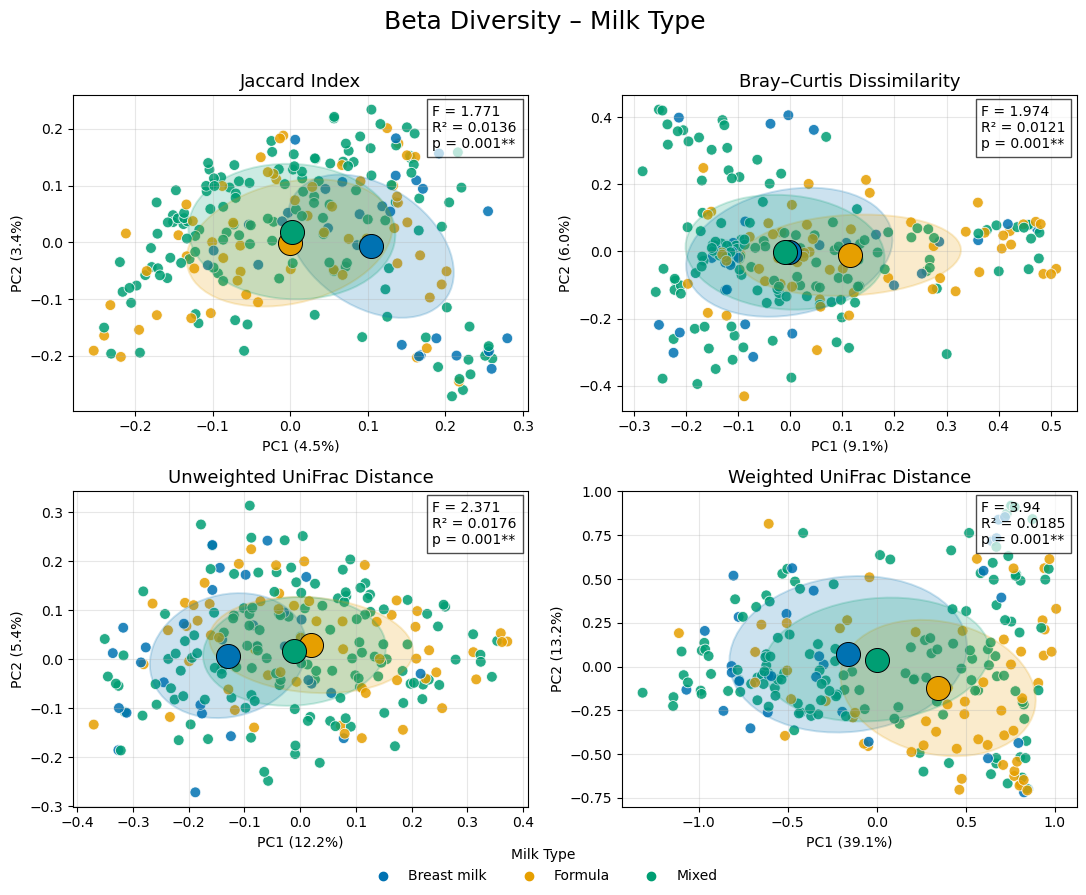


PCoA PLOTS FOR: diet_weaning


/tmp/ipykernel_426/1703833388.py:29: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df[column] = df[column].replace(rename_dict).astype("category")
/tmp/ipykernel_426/1630200619.py:102: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, sub in df.groupby(column):
/tmp/ipykernel_426/1703833388.py:29: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df[column] = df[column].re

Saved figure to: ../data/processed/diversity/depth-14000_no-filter/beta/metrics/pcoa_plots/diet_weaning_PCoA_with_stats.png


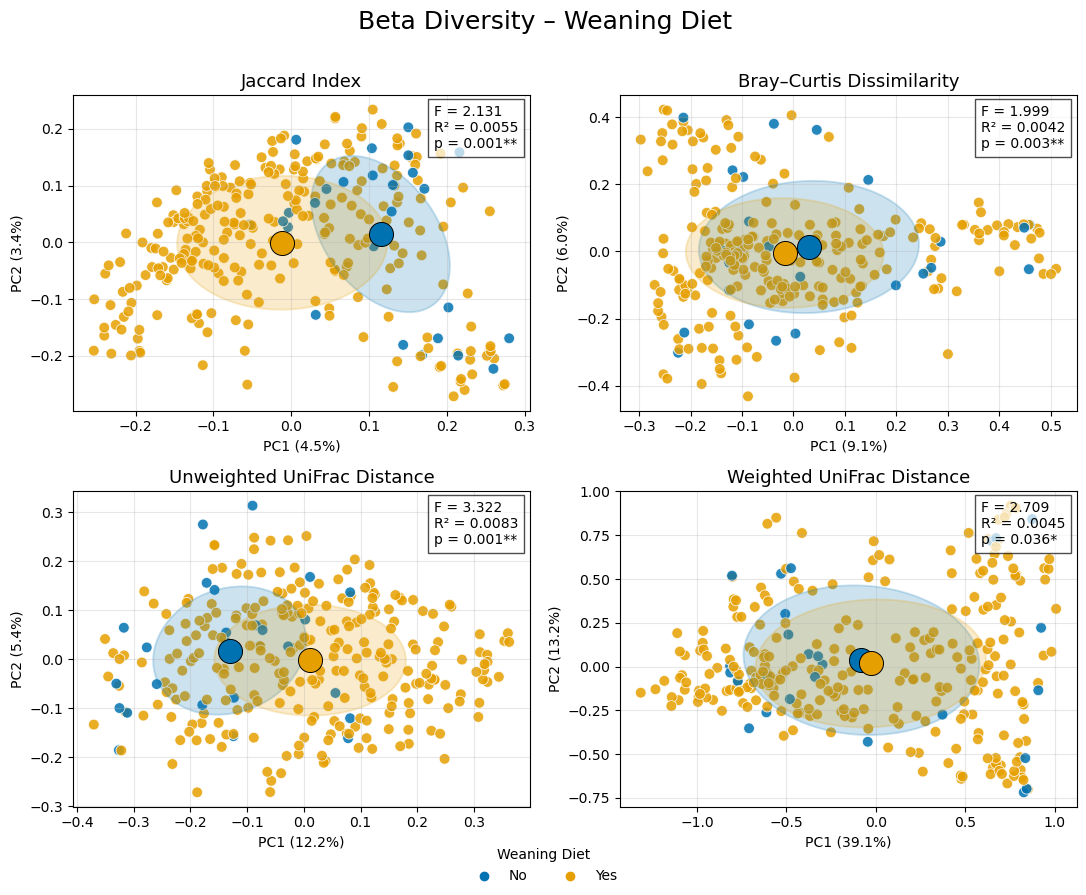


PCoA PLOTS FOR: age_months


/tmp/ipykernel_426/1630200619.py:102: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, sub in df.groupby(column):
/tmp/ipykernel_426/1630200619.py:102: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, sub in df.groupby(column):
/tmp/ipykernel_426/1630200619.py:102: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, sub in df.groupby(column):
/tmp/ipykernel_426/1630200619.py:102: FutureWarning: The d

Saved figure to: ../data/processed/diversity/depth-14000_no-filter/beta/metrics/pcoa_plots/age_months_PCoA_with_stats.png


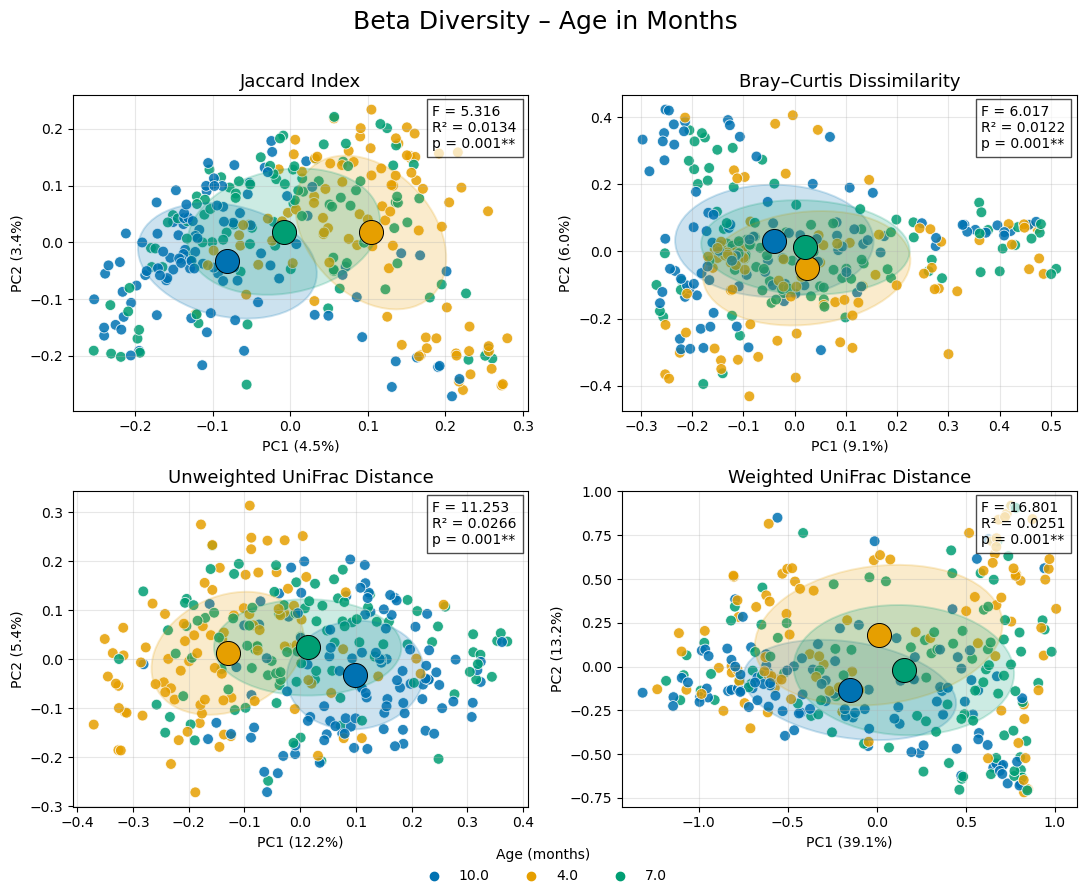

In [62]:
# Metric labels used to give cleaner, more descriptive titles to the PCoA plots.
# This helps make the figures easier to interpret across the four beta metrics.
metric_labels = {
    "Bray–Curtis": "Bray–Curtis Dissimilarity",
    "Jaccard": "Jaccard Index",
    "Unweighted UniFrac": "Unweighted UniFrac Distance",
    "Weighted UniFrac": "Weighted UniFrac Distance"
}

# Rename dictionaries for the metadata groups we want to visualize.
# These make the plot legends understandable instead of showing coded labels.
rename_milk = {
    "bd": "Breast milk",
    "fd": "Formula",
    "mixed": "Mixed"
}

# Rename dictionary for weaning categories.
# Adjust these values if your dataset uses different labels.
rename_weaning = {
    "yes": "Yes",
    "no": "No"
}

# age_months is numeric, so it does not need renaming.


# ----- Plot 1: diet_milk -----
# Here we visualize clustering patterns across beta diversity metrics
# colored by milk type. This variable changes over time, meaning
# both the visualization AND the PERMANOVA statistics are meaningful.
print("\n" + "="*80)
print("PCoA PLOTS FOR: diet_milk")
print("="*80)

plot_all_metrics_for_column_with_stats(
    column="diet_milk",
    rename_dict=rename_milk,
    metric_labels=metric_labels,
    legend_title="Milk Type",
    legend_position="lower center",
    figure_title="Beta Diversity – Milk Type",
    centroid_marker="o"
)


# ----- Plot 2: diet_weaning -----
# Same idea as above, but now focusing on weaning status.
# Since this also changes over time, the PERMANOVA results shown
# inside each plot (F, R², p) can be interpreted meaningfully.
print("\n" + "="*80)
print("PCoA PLOTS FOR: diet_weaning")
print("="*80)

plot_all_metrics_for_column_with_stats(
    column="diet_weaning",
    rename_dict=rename_weaning,
    metric_labels=metric_labels,
    legend_title="Weaning Diet",
    legend_position="lower center",
    figure_title="Beta Diversity – Weaning Diet",
    centroid_marker="o"
)


# ----- Plot 3: age_months -----
# Age is continuous and increases with each timepoint.
# This plot helps visualize how microbiome structure gradually shifts
# as infants grow older. PERMANOVA results are added inside each panel.
print("\n" + "="*80)
print("PCoA PLOTS FOR: age_months")
print("="*80)

plot_all_metrics_for_column_with_stats(
    column="age_months",
    rename_dict=None,   # numeric variable
    metric_labels=metric_labels,
    legend_title="Age (months)",
    legend_position="lower center",
    figure_title="Beta Diversity – Age in Months",
    centroid_marker="o"
)


<div style="border: 2px solid #1f77b4; padding: 10px; border-radius: 6px; background-color: #eaf3fb;">
<b> Answers to the research questions:</b>

- How does alpha diversity (e.g., richness, Shannon diversity) vary with age and across metadata groups such as feeding pattern, delivery mode, treatment, and geographic location?
  - We explored alpha diversity patterns and used Kruskal–Wallis tests to check for group differences. These initial results suggest that alpha diversity may vary across several metadata categories. However, because these tests do not account for repeated measurements from the same infants, they cannot be interpreted as final evidence. To draw reliable conclusions, we will re-analyze alpha diversity using appropriate longitudinal methods (QIIME2’s longitudinal plugin or linear mixed-effects models), which correctly handle within-infant correlations. This longitudinal analysis will be performed in the next notebook and will provide further answer to this question.
    


- How does beta diversity (community composition differences) vary with age and between metadata groups, and which factors explain the largest share of variation?
  - Our PERMANOVA analysis (adjusting for repeated measures using host_id) only produces valid results for variables that change over time, meaning we cannot currently evaluate delivery mode, treatment exposure, or geographic location, because the statistical model cannot separate their effects from infant-specific variation. For the variables that do vary longitudinally (age_months, diet_milk, and diet_weaning) we observe clear patterns: age explains the largest share of variation across metrics, showing strong shifts in community composition as infants grow; diet_milk has significant effects, indicating differences in microbiome structure between feeding types; and diet_weaning also contributes meaningfully, consistent with the transition to solid foods. 

</div>


### Optional Cleanup: Remove an Old Run Directory

This block is optional. If you want to re-run the pipeline from scratch with the same parameters, you can delete the existing run directory first. The code is commented out to avoid accidentally removing data.

In [ ]:
# ======================================================
# DELETE RUN DIRECTORY 
# ======================================================
# Uncomment the lines below to delete the entire run_dir.
# This is useful if you want to re-run the pipeline cleanly
# with the same sampling depth or filters.
# ======================================================

# folder_to_delete = run_dir
# #folder_to_delete = f"{diversity_data_dir}/depth-14000_no-filter"

# if os.path.exists(folder_to_delete):
#     print("Fast deletion with verbose output...\n")
#     !rm -rfv {folder_to_delete}
#     print("Directory deleted.")
# else:
#     print("Unsafe path — aborting.")

# References

QIIME 2 Documentation. (2024). core-metrics-phylogenetic: Core diversity metrics (phylogenetic and non-phylogenetic). https://docs.qiime2.org/2024.10/plugins/available/diversity/core-metrics-phylogenetic/

National Cancer Institute, Center for Cancer Research. QIIME 2: Lesson 5 — Microbial Diversity and Core Metrics. https://bioinformatics.ccr.cancer.gov/docs/qiime2/Lesson5/
